# K-Means Clustering — Wholesale Customers Data Set

The UCI wholesale customers dataset records annual spending
(monetary units) on fresh food, milk, grocery, frozen
products, detergents/paper, and delicatessen for Portuguese
wholesale clients, along with `Channel` (HoReCa vs Retail)
and `Region`.

We cluster on the **six spending columns** only (excluding
`Channel` and `Region`) after log1p scaling so heavy-tailed
spend amounts do not dominate Euclidean distance.

K-means minimizes within-cluster inertia; Lloyd's algorithm
alternates assignment and centroid updates.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.processing.datasets import find_data_file

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4.5)

In [2]:
from rice_ml.unsupervised_learning.clustering import KMeans
from rice_ml.processing.metrics import silhouette_score

df = pd.read_csv(find_data_file("Wholesale_customers_data.csv"))
spend_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
X = np.log1p(df[spend_cols].to_numpy(dtype=float))

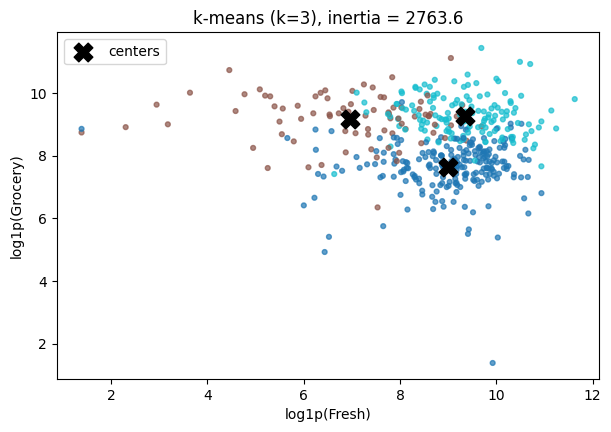

In [3]:
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 2], c=km.labels_, cmap="tab10", s=12, alpha=0.7)
ax.scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 2],
    marker="X",
    s=180,
    color="black",
    label="centers",
)
ax.set_xlabel("log1p(Fresh)")
ax.set_ylabel("log1p(Grocery)")
ax.set_title(f"k-means (k=3), inertia = {km.inertia_:.1f}")
ax.legend()
plt.show()

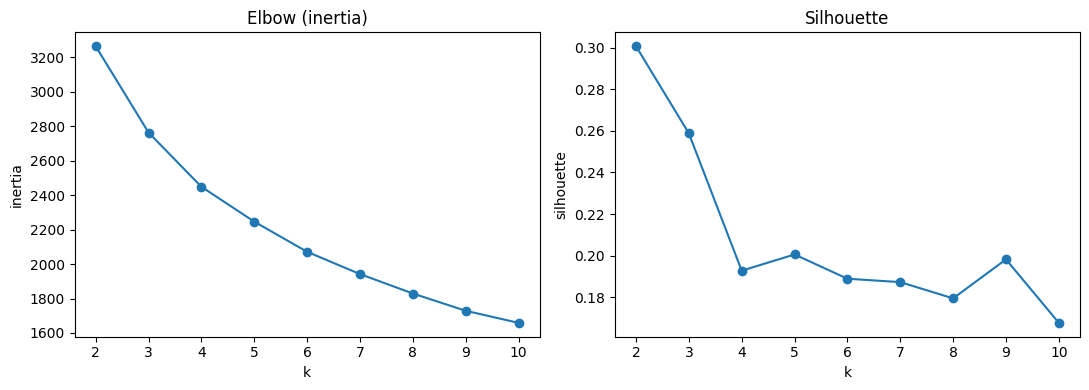

In [4]:
ks = list(range(2, 11))
inertias = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(X).inertia_ for k in ks]
sils = [
    silhouette_score(X, KMeans(n_clusters=k, n_init=10, random_state=0).fit(X).labels_)
    for k in ks
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks, inertias, marker="o")
axes[0].set_title("Elbow (inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[1].plot(ks, sils, marker="o")
axes[1].set_title("Silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette")
plt.tight_layout()
plt.show()

## Takeaways

- Log scaling stabilizes k-means when features are skewed
  and span different magnitudes.
- Elbow and silhouette plots rarely agree perfectly; use
  both plus domain sense (e.g. customer segments).
- `Channel` can be compared *after* clustering to see
  whether segments align with business type.